# Phase 1 — Data Audit, Cleaning & EDA

Weekly demand forecasting for ~13 725 cinnamon products.
This notebook runs `src.data_cleaning.load_clean()`, prints the data-quality
report, and saves numbered figures to `outputs/figures/`.

In [1]:
import sys
from pathlib import Path

# Resolve project root regardless of where the kernel is launched from.
ROOT = Path().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

from src.data_cleaning import load_clean

FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
RAW_XLSX = ROOT / "data" / "raw" / "Cinnamon_export_sales.xlsx"
PARQUET  = ROOT / "data" / "processed" / "transactions_clean.parquet"

# ── Project-wide style (applied once; all figures inherit it) ─────────────────
plt.rcParams.update({
    "figure.dpi"        : 100,
    "savefig.dpi"       : 140,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#f8f8f8",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.35,
    "grid.color"        : "#cccccc",
    "font.family"       : "sans-serif",
    "font.size"         : 10,
    "axes.titlesize"    : 12,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 10,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "legend.fontsize"   : 9,
    "legend.frameon"    : False,
})

C = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B", "#44BBA4"]

def savefig(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight", dpi=140)
    print(f"Saved → {name}")


In [2]:
# ── 1. Load raw data (needed for before-cleaning analysis) ───────────────────
raw = pd.read_excel(RAW_XLSX, sheet_name="Sheet1")
print(f"Raw: {len(raw):,} rows  |  columns: {list(raw.columns)}")


Raw: 60,670 rows  |  columns: ['Region', 'Country', 'Customer Code', 'Customer ID', 'Brand Category', 'Product Range', 'Sales Channel', 'Product Code', 'Order Date', 'Invoice Date', 'Invoice No', 'Sales USD', 'Sales Qty', 'Sales KG']


In [3]:
# ── 2. Run cleaning pipeline (saves Parquet, returns summary dict) ────────────
summary = load_clean(raw_path=RAW_XLSX, out_path=PARQUET)

# ── 3. Load cleaned transactions ─────────────────────────────────────────────
df = pd.read_parquet(PARQUET)
print(f"Clean: {len(df):,} rows  |  date range: "
      f"{df['Order Date'].min().date()} → {df['Order Date'].max().date()}")


Clean: 60,667 rows  |  date range: 2022-02-28 → 2025-09-17


In [4]:
# ── Pareto thresholds ─────────────────────────────────────────────────────────
prod_qty = (
    df.groupby("ProductID")["Sales Qty"]
    .sum()
    .clip(lower=0)                   # net-negative products count as 0
    .sort_values(ascending=False)
)
total_qty = prod_qty.sum()
cum_frac  = prod_qty.cumsum() / total_qty
n_prod    = len(prod_qty)

def _pareto_n(thr: float) -> int:
    return int((cum_frac <= thr).sum()) + 1

p50, p80, p95 = _pareto_n(0.50), _pareto_n(0.80), _pareto_n(0.95)

# ── Data quality report ───────────────────────────────────────────────────────
SEP = "=" * 62
print(SEP)
print("DATA QUALITY REPORT — Phase 1")
print(SEP)
print(f"  Rows in  (raw)                   {summary['rows_raw']:>10,}")
print(f"  Dropped  corrupt (Qty > 1 M)     {summary['rows_dropped_corrupt']:>10,}")
print(f"  Dropped  product 43962-015       {summary['rows_dropped_product_43962_015']:>10,}")
print(f"  Order Date backfilled from Inv.  {summary['nulls_order_date_backfilled']:>10,}")
print(f"  Dropped  no usable date          {summary['rows_dropped_no_date']:>10,}")
print(f"  Rows out (clean)                 {summary['rows_clean']:>10,}")
print()
print(f"  Return rows  (Sales Qty < 0)     {summary['returns_count']:>10,}")
print(f"  Promo rows   (Sales USD <= 0)    {summary['promo_rows']:>10,}")
print()
print(f"  Unique products (raw, first-9)   {summary['products_raw']:>10,}")
print(f"  Unique products (clean)          {summary['products_clean']:>10,}")
print()
print(f"  Pareto thresholds ({n_prod:,} products total):")
print(f"    50 % of qty  ->  {p50:>6,} products  ({p50 / n_prod:.1%} of catalogue)")
print(f"    80 % of qty  ->  {p80:>6,} products  ({p80 / n_prod:.1%} of catalogue)")
print(f"    95 % of qty  ->  {p95:>6,} products  ({p95 / n_prod:.1%} of catalogue)")
print(SEP)


DATA QUALITY REPORT — Phase 1
  Rows in  (raw)                       60,670
  Dropped  corrupt (Qty > 1 M)              1
  Dropped  product 43962-015                2
  Order Date backfilled from Inv.         139
  Dropped  no usable date                   0
  Rows out (clean)                     60,667

  Return rows  (Sales Qty < 0)            140
  Promo rows   (Sales USD <= 0)         6,827

  Unique products (raw, first-9)       13,725
  Unique products (clean)              13,724

  Pareto thresholds (13,724 products total):
    50 % of qty  ->      97 products  (0.7% of catalogue)
    80 % of qty  ->     677 products  (4.9% of catalogue)
    95 % of qty  ->   2,674 products  (19.5% of catalogue)


Saved → 01_missingness_map.png


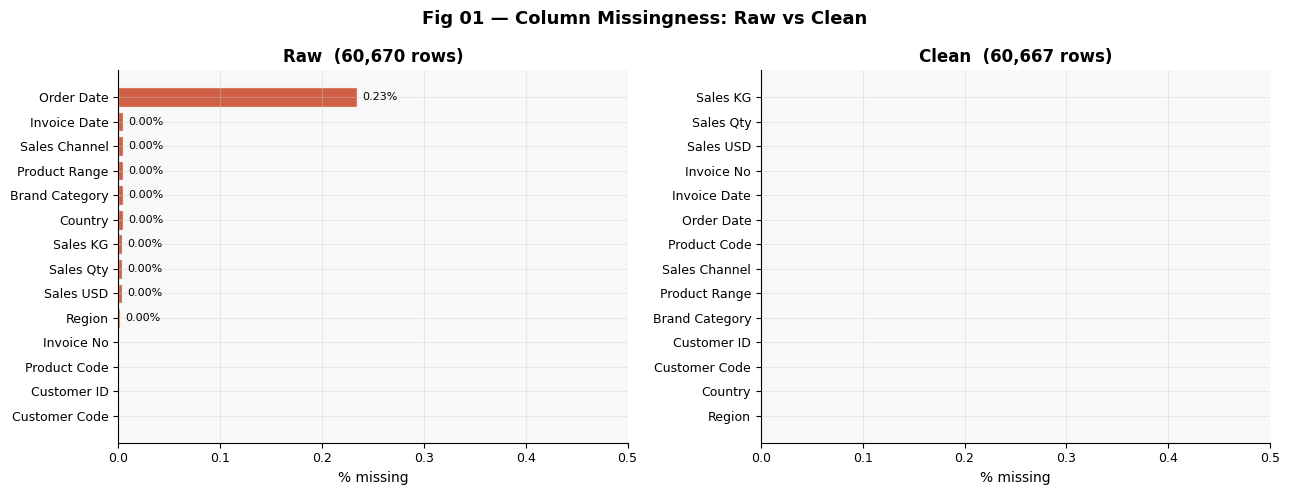

In [5]:
# ── Fig 01 — Missingness map (raw vs clean) ───────────────────────────────────
def _miss_pct(frame):
    return (frame.isna().mean() * 100).sort_values(ascending=True)

raw_miss   = _miss_pct(raw)
clean_miss = _miss_pct(df[raw.columns])   # compare same columns only

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Fig 01 — Column Missingness: Raw vs Clean", fontsize=13, fontweight="bold")

for ax, miss, label, color in zip(
    axes,
    [raw_miss, clean_miss],
    [f"Raw  ({len(raw):,} rows)", f"Clean  ({len(df):,} rows)"],
    [C[3], C[0]],
):
    bars = ax.barh(miss.index, miss.values, color=color, alpha=0.82, edgecolor="white")
    ax.set_xlabel("% missing")
    ax.set_title(label)
    limit = max(raw_miss.max() * 1.20, 0.5)
    ax.set_xlim(0, limit)
    for bar, val in zip(bars, miss.values):
        if val > 0.001:
            ax.text(val + limit * 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{val:.2f}%", va="center", fontsize=8)

plt.tight_layout()
savefig(fig, "01_missingness_map.png")
plt.show()


Saved → 02_qty_distribution.png


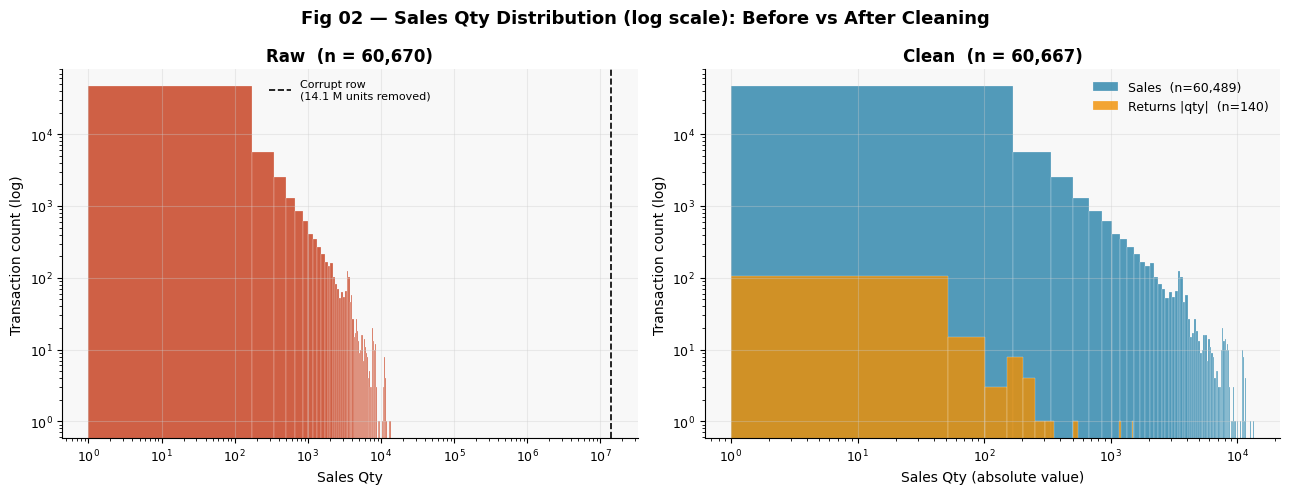

In [6]:
# ── Fig 02 — Sales Qty distribution (log) before vs after cleaning ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Fig 02 — Sales Qty Distribution (log scale): Before vs After Cleaning",
             fontsize=13, fontweight="bold")

# Before — raw (includes the >1 M corrupt outlier)
ax = axes[0]
raw_pos = raw["Sales Qty"].dropna()
raw_pos_clean = raw_pos[raw_pos.between(1, 1_000_000)]
ax.hist(raw_pos_clean, bins=80, color=C[3], alpha=0.82, log=True, edgecolor="white", lw=0.2)
corrupt_qty = int(raw["Sales Qty"].max())
ax.axvline(corrupt_qty, color="black", ls="--", lw=1.2,
           label=f"Corrupt row\n({corrupt_qty/1e6:.1f} M units removed)")
ax.set_xscale("log")
ax.set_xlabel("Sales Qty")
ax.set_ylabel("Transaction count (log)")
ax.set_title(f"Raw  (n = {len(raw):,})")
ax.legend(fontsize=8)

# After — clean (returns shown separately)
ax2 = axes[1]
pos = df[df["Sales Qty"] > 0]["Sales Qty"]
neg = df[df["Sales Qty"] < 0]["Sales Qty"].abs()
ax2.hist(pos, bins=80, color=C[0], alpha=0.82, log=True, edgecolor="white", lw=0.2,
         label=f"Sales  (n={len(pos):,})")
ax2.hist(neg, bins=30, color=C[2], alpha=0.8, log=True, edgecolor="white", lw=0.2,
         label=f"Returns |qty|  (n={len(neg):,})")
ax2.set_xscale("log")
ax2.set_xlabel("Sales Qty (absolute value)")
ax2.set_ylabel("Transaction count (log)")
ax2.set_title(f"Clean  (n = {len(df):,})")
ax2.legend()

plt.tight_layout()
savefig(fig, "02_qty_distribution.png")
plt.show()


Saved → 03_transactions_per_product.png


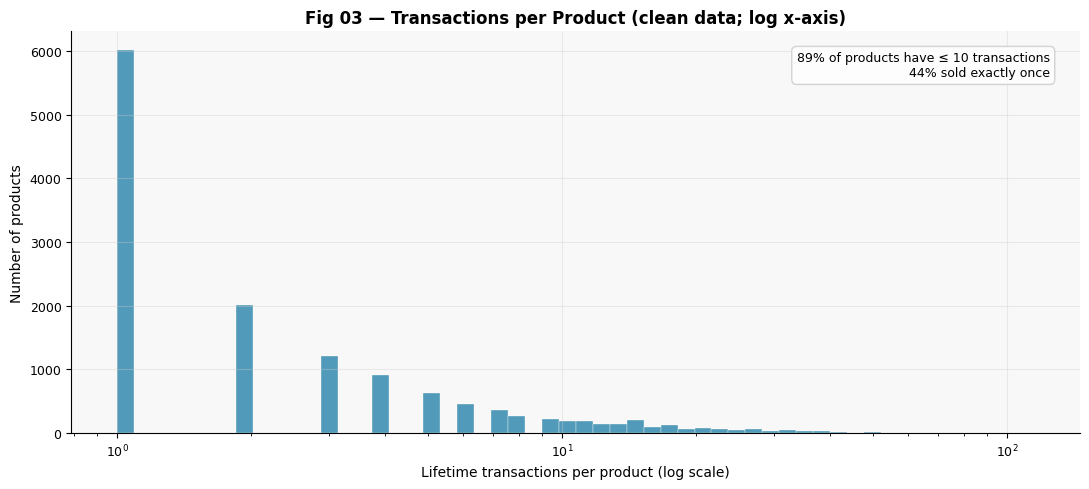

In [7]:
# ── Fig 03 — Transactions-per-product histogram ───────────────────────────────
tx_per_prod = df.groupby("ProductID").size()
pct_le10 = (tx_per_prod <= 10).mean() * 100
pct_once  = (tx_per_prod == 1).mean() * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title("Fig 03 — Transactions per Product (clean data; log x-axis)")

bins = np.logspace(0, np.log10(tx_per_prod.max() + 1), 55)
ax.hist(tx_per_prod, bins=bins, color=C[0], alpha=0.82, edgecolor="white", lw=0.3)
ax.set_xscale("log")
ax.set_xlabel("Lifetime transactions per product (log scale)")
ax.set_ylabel("Number of products")

textbox = (
    f"{pct_le10:.0f}% of products have \u2264 10 transactions\n"
    f"{pct_once:.0f}% sold exactly once"
)
ax.text(0.97, 0.95, textbox, transform=ax.transAxes, ha="right", va="top",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85, ec="#cccccc"))

plt.tight_layout()
savefig(fig, "03_transactions_per_product.png")
plt.show()


Saved → 04_abc_pareto.png


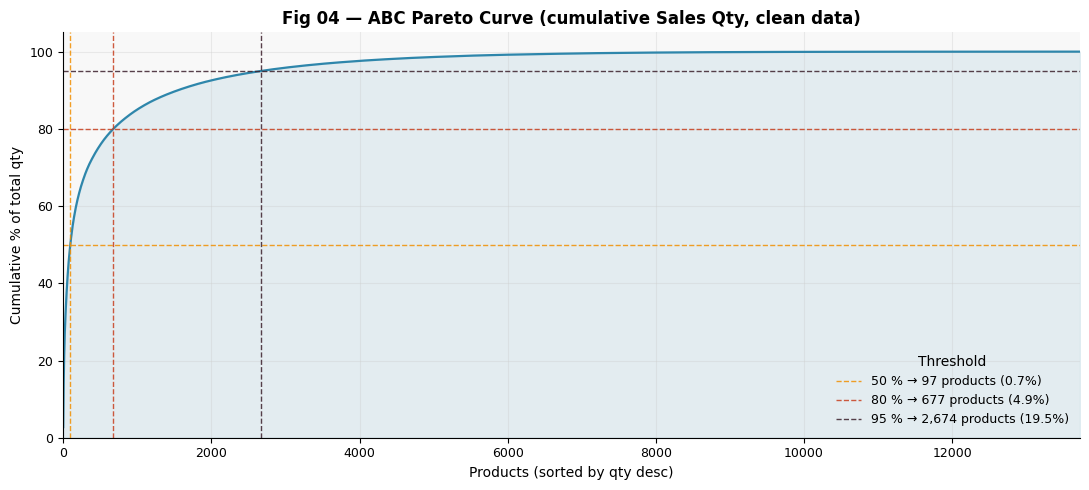

In [8]:
# ── Fig 04 — ABC Pareto curve ─────────────────────────────────────────────────
x = np.arange(1, n_prod + 1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title("Fig 04 — ABC Pareto Curve (cumulative Sales Qty, clean data)")

ax.plot(x, cum_frac.values * 100, color=C[0], lw=1.6)
ax.fill_between(x, cum_frac.values * 100, alpha=0.10, color=C[0])

thresholds = [(50, p50, C[2], "A boundary (80 %)"),
              (80, p80, C[3], "B boundary (95 %)"),
              (95, p95, C[4], "C boundary (95 %)")]

for pct, n, col, _ in [(50, p50, C[2], ""), (80, p80, C[3], ""), (95, p95, C[4], "")]:
    ax.axhline(pct, ls="--", lw=1, color=col, alpha=0.85)
    ax.axvline(n,   ls="--", lw=1, color=col, alpha=0.85,
               label=f"{pct} % → {n:,} products ({n/n_prod:.1%})")

ax.set_xlabel("Products (sorted by qty desc)")
ax.set_ylabel("Cumulative % of total qty")
ax.set_xlim(0, n_prod)
ax.set_ylim(0, 105)
ax.legend(title="Threshold", loc="lower right")

plt.tight_layout()
savefig(fig, "04_abc_pareto.png")
plt.show()


Saved → 05_qty_by_segment.png


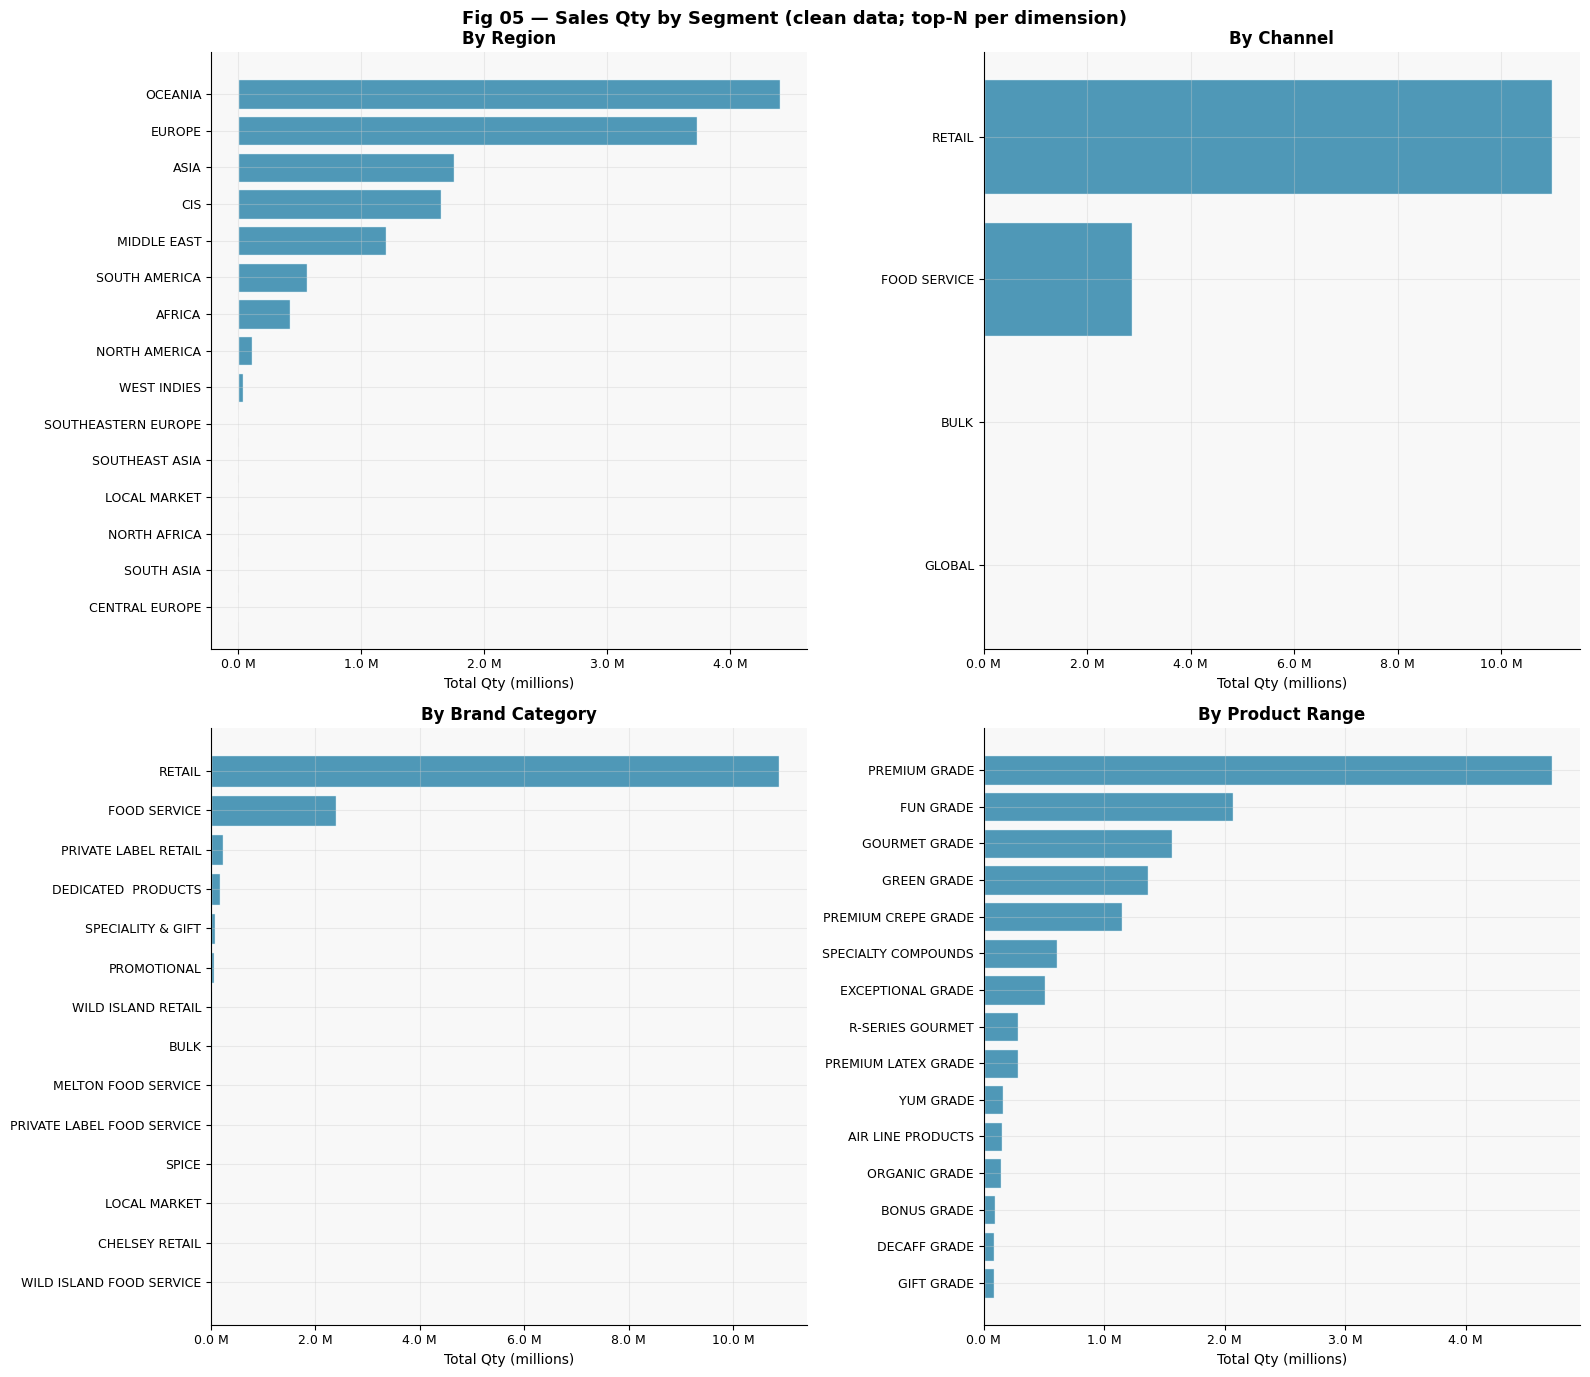

In [9]:
# ── Fig 05 — Sales Qty by segment (region / channel / brand / range) ──────────
DIMS = [
    ("Region",         "Region",         15),
    ("Sales Channel",  "Channel",         4),
    ("Brand Category", "Brand Category", 14),
    ("Product Range",  "Product Range",  15),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Fig 05 — Sales Qty by Segment (clean data; top-N per dimension)",
             fontsize=13, fontweight="bold")

for ax, (col, label, topn) in zip(axes.flat, DIMS):
    grp = (df.groupby(col)["Sales Qty"].sum()
             .nlargest(topn).sort_values(ascending=True))
    bars = ax.barh(grp.index, grp.values / 1e6, color=C[0], alpha=0.84, edgecolor="white")
    ax.set_title(f"By {label}")
    ax.set_xlabel("Total Qty (millions)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f} M"))

plt.tight_layout()
savefig(fig, "05_qty_by_segment.png")
plt.show()


Saved → 06_revenue_by_segment.png


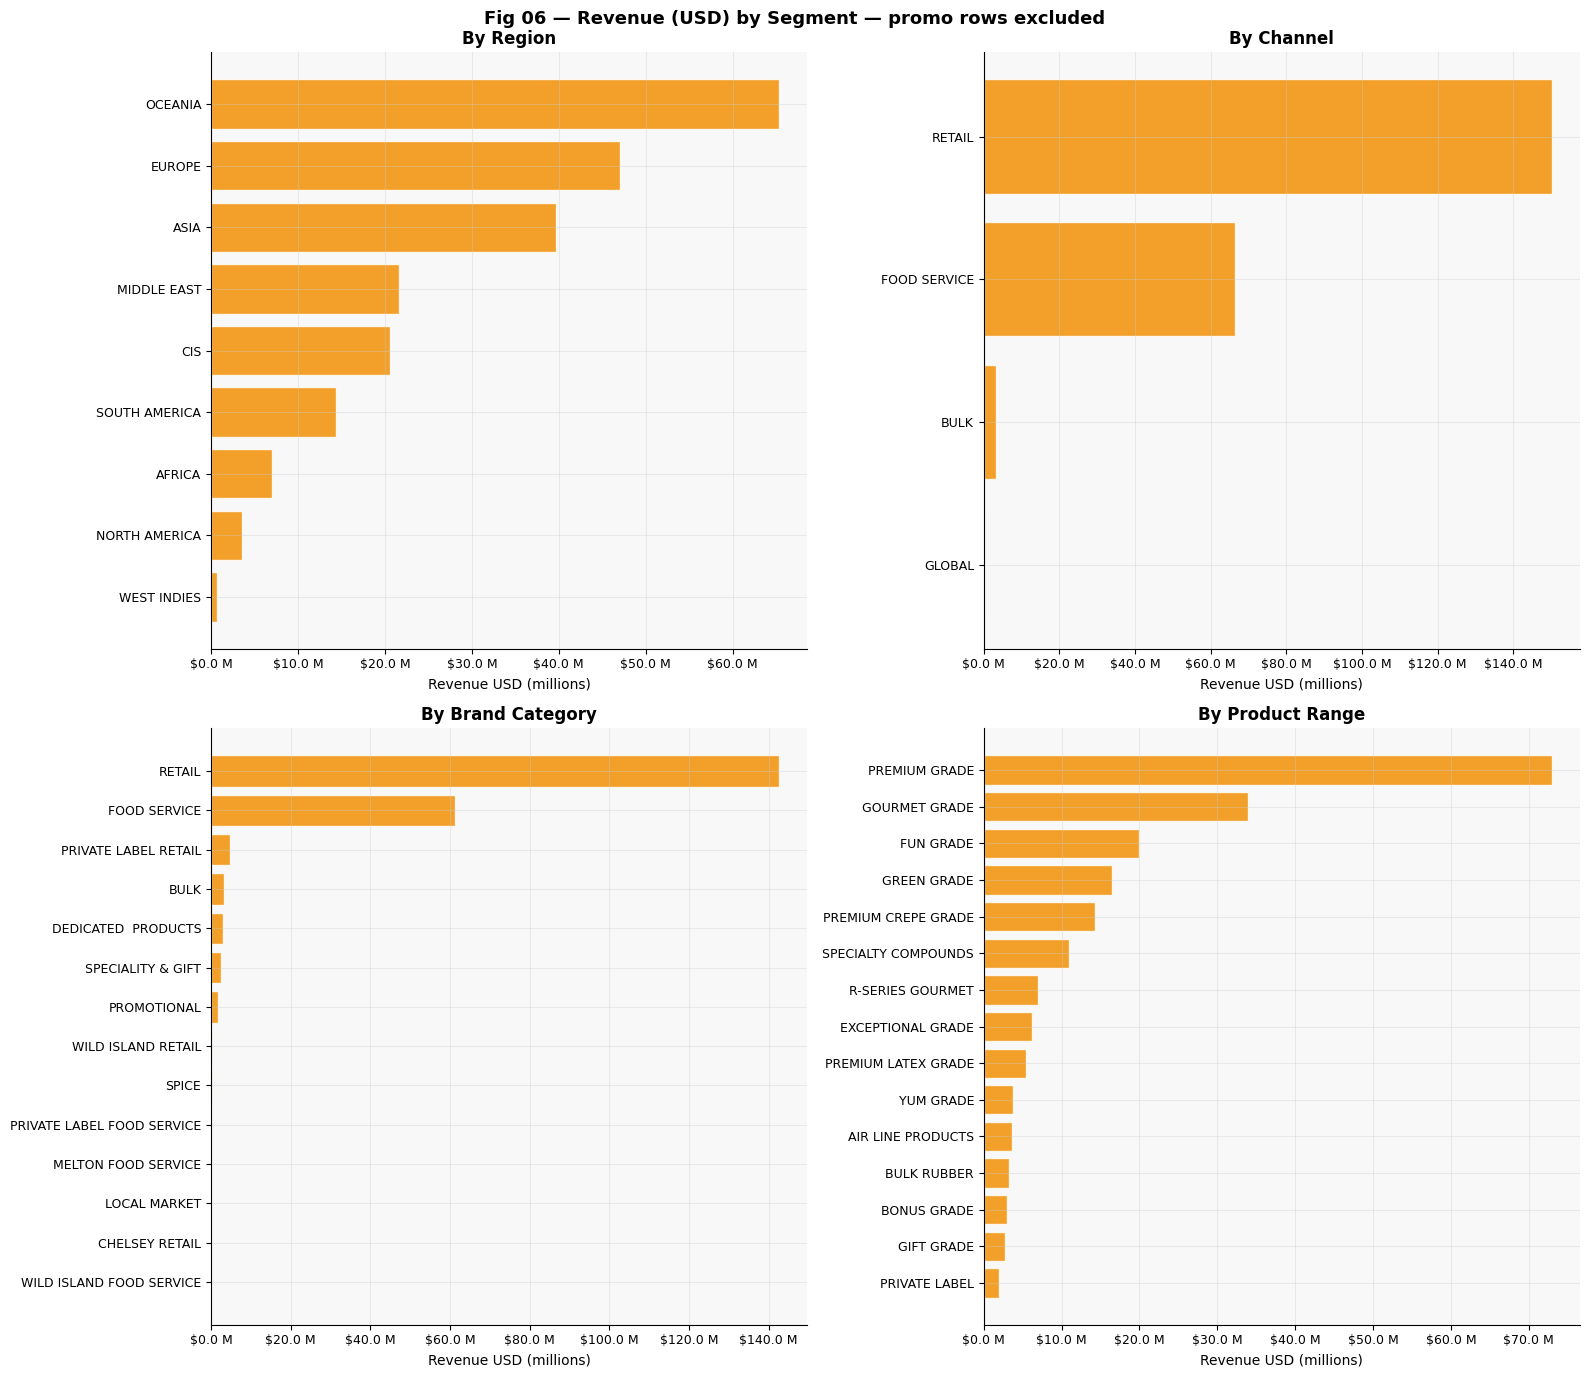

In [10]:
# ── Fig 06 — Revenue (USD) by segment — promo rows excluded ──────────────────
df_rev = df[df["is_promo"] == 0]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Fig 06 — Revenue (USD) by Segment — promo rows excluded",
             fontsize=13, fontweight="bold")

for ax, (col, label, topn) in zip(axes.flat, DIMS):
    grp = (df_rev.groupby(col)["Sales USD"].sum()
                 .nlargest(topn).sort_values(ascending=True))
    ax.barh(grp.index, grp.values / 1e6, color=C[2], alpha=0.84, edgecolor="white")
    ax.set_title(f"By {label}")
    ax.set_xlabel("Revenue USD (millions)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.1f} M"))

plt.tight_layout()
savefig(fig, "06_revenue_by_segment.png")
plt.show()


Saved → 07_monthly_qty_trend.png


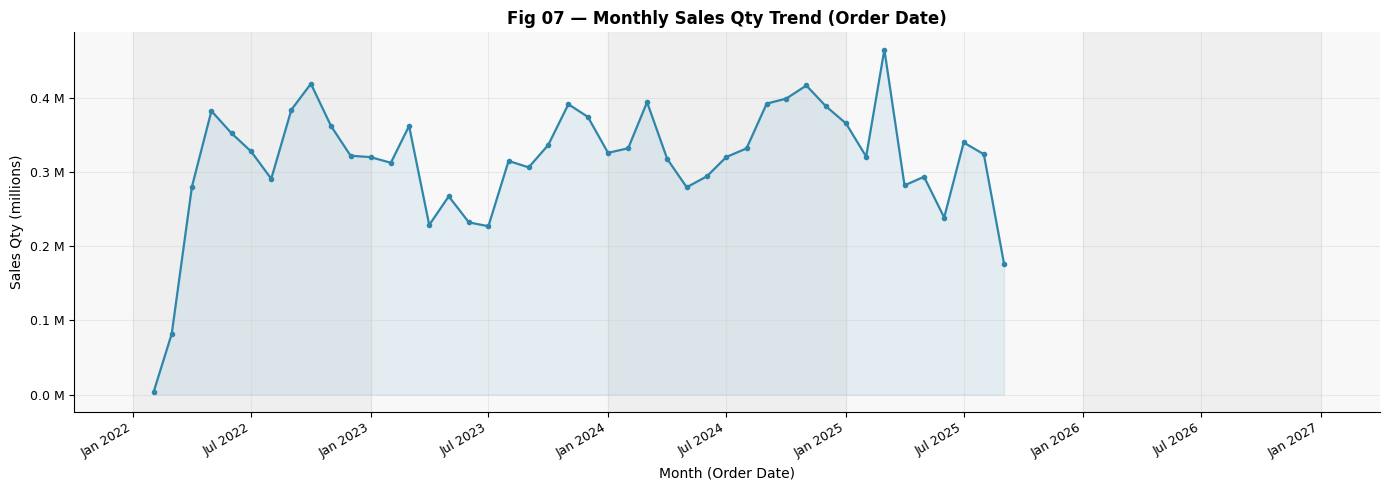

In [11]:
# ── Fig 07 — Monthly Sales Qty trend ─────────────────────────────────────────
monthly = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales Qty"]
    .sum()
    .reset_index()
)
monthly.columns = ["period", "qty"]
monthly["date"] = monthly["period"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title("Fig 07 — Monthly Sales Qty Trend (Order Date)")

ax.plot(monthly["date"], monthly["qty"] / 1e6, color=C[0], lw=1.6, marker="o", ms=3)
ax.fill_between(monthly["date"], monthly["qty"] / 1e6, alpha=0.10, color=C[0])

# Shade calendar years alternately
for yr in range(monthly["date"].dt.year.min(), monthly["date"].dt.year.max() + 2):
    start = pd.Timestamp(f"{yr}-01-01")
    end   = pd.Timestamp(f"{yr+1}-01-01")
    if yr % 2 == 0:
        ax.axvspan(start, end, color="#e8e8e8", alpha=0.5, zorder=0)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.set_xlabel("Month (Order Date)")
ax.set_ylabel("Sales Qty (millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f} M"))

plt.tight_layout()
savefig(fig, "07_monthly_qty_trend.png")
plt.show()


Saved → 08_yoy_qty_trend.png


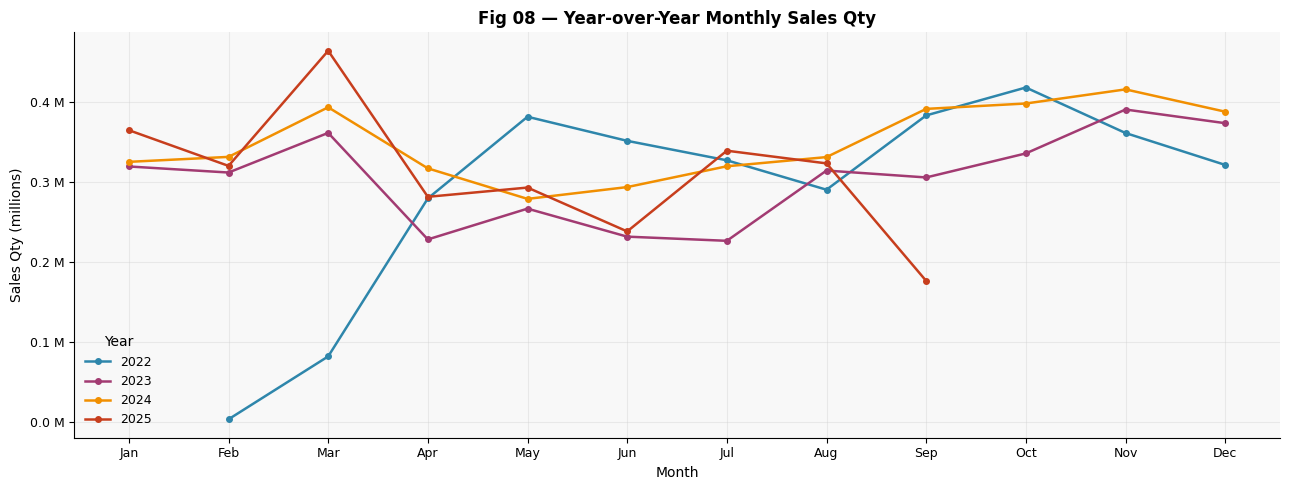

In [12]:
# ── Fig 08 — Year-over-year monthly Sales Qty ────────────────────────────────
df["_year"]  = df["Order Date"].dt.year
df["_month"] = df["Order Date"].dt.month

yoy = df.groupby(["_year", "_month"])["Sales Qty"].sum().reset_index()
pivot = yoy.pivot(index="_month", columns="_year", values="Sales Qty")

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title("Fig 08 — Year-over-Year Monthly Sales Qty")

for i, yr in enumerate(sorted(pivot.columns)):
    ax.plot(pivot.index, pivot[yr] / 1e6,
            color=C[i % len(C)], lw=1.8, marker="o", ms=4, label=str(yr))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_xlabel("Month")
ax.set_ylabel("Sales Qty (millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f} M"))
ax.legend(title="Year")

# Drop temp columns
df.drop(columns=["_year", "_month"], inplace=True)

plt.tight_layout()
savefig(fig, "08_yoy_qty_trend.png")
plt.show()


In [13]:
print("\nPhase 1 complete — all figures saved to outputs/figures/")
import os
for f in sorted((ROOT / "outputs" / "figures").iterdir()):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")



Phase 1 complete — all figures saved to outputs/figures/
  01_missingness_map.png  (81 KB)
  02_qty_distribution.png  (62 KB)
  03_transactions_per_product.png  (43 KB)
  04_abc_pareto.png  (67 KB)
  05_qty_by_segment.png  (167 KB)
  06_revenue_by_segment.png  (158 KB)
  07_monthly_qty_trend.png  (77 KB)
  08_yoy_qty_trend.png  (111 KB)
